# The state paradigm

**What you'll learn / who it's for (simulation *and* training).** Why a functional
array library like JAX needs an explicit notion of *state*, how ``brainpy.state``
provides it, and how to advance a model through time the right way — never with a
bare Python loop. Everything else in the documentation builds on these primitives.

## The problem: dynamics without mutable variables

A spiking network *is* state evolving in time: membrane potentials, synaptic
conductances, eligibility traces. But JAX — the engine underneath
``brainpy.state`` — is **functional**. Its arrays are immutable, and its real power
(``jit`` compilation, ``grad`` automatic differentiation, ``vmap`` batching) comes
from transforming *pure* functions that take values in and return values out.

Threading every hidden variable through every function call by hand would be
unbearable for anything larger than a single neuron. ``brainstate.State`` resolves
the tension: state is held in explicit, trackable containers, so your model code
reads imperatively, while the framework still hands JAX the pure functions it
needs. (``brainpy.state`` is the point-neuron layer built on ``brainstate``; the
two names appear side by side throughout.)

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## `State`: a trackable, differentiable variable

A ``State`` wraps a value (almost always a JAX array, usually carrying physical
units) and exposes it through ``.value``. You read and write ``.value`` like an
ordinary attribute, but because the container is *tracked*, the framework can
collect it, batch it, checkpoint it, and route gradients through it.

In [2]:
# A scalar state and a matrix state.
voltage = brainstate.State(-65.0 * u.mV)
weights = brainstate.State(jnp.array([[0.1, 0.2], [0.3, 0.4]]))

# Read and update through .value
print(voltage.value)
voltage.value = voltage.value + 5.0 * u.mV
print(voltage.value)

-65. mV
-60. mV


### State *types* carry intent

``brainpy.state`` distinguishes states by role, and transformations key off the
distinction:

- **``ParamState``** — trainable parameters (weights, learnable time constants).
  ``brainstate.transform.grad`` differentiates with respect to these.
- **``ShortTermState`` / ``HiddenState``** — dynamical variables that evolve every
  step (membrane potential, conductance) and are reset between runs.

You rarely create these by hand — the built-in neurons and synapses declare them
for you — but knowing the split explains how training selects exactly the right
variables:

In [3]:
class LeakyUnit(brainstate.nn.Module):
    def __init__(self, size, tau=10.0 * u.ms):
        super().__init__()
        self.tau = brainstate.ParamState(tau)              # trainable
        self.v = brainstate.ShortTermState(jnp.zeros(size) * u.mV)  # dynamical

    def update(self, x):
        dt = brainstate.environ.get_dt()
        self.v.value = self.v.value + (-self.v.value + x) / self.tau.value * dt
        return self.v.value

## `init_all_states`: allocate the dynamical variables

A freshly constructed model knows its *parameters* but has not yet allocated its
*dynamical* state — that depends on the batch size you want to run. One call walks
the whole module tree and initializes every state:

In [4]:
neuron = brainpy.state.LIF(
    100,
    V_rest=-65. * u.mV, V_th=-50. * u.mV, V_reset=-65. * u.mV,
    tau=10. * u.ms,
)

# Allocate states for a single trial ...
brainstate.nn.init_all_states(neuron)
print('unbatched V shape:', neuron.V.value.shape)

# ... or for a batch of 32 trials run in parallel.
brainstate.nn.init_all_states(neuron, batch_size=32)
print('batched   V shape:', neuron.V.value.shape)

unbatched V shape: (100,)
batched   V shape: (32, 100)


Call ``init_all_states`` again whenever you want to **reset** the model — for
example at the start of every training epoch, so each minibatch starts from a clean
slate (you'll see exactly this in {doc}`/concepts/differentiability`).

## `environ.context`: the simulation clock

Discrete-time dynamics need a time step ``dt`` (and often the current time ``t``).
Rather than thread these through every call, ``brainpy.state`` reads them from a
context manager. Set ``dt`` once around your run; set ``t`` inside the per-step
function so time-dependent inputs and synapses see the right value.

In [5]:
with brainstate.environ.context(dt=0.1 * u.ms):
    print('dt =', brainstate.environ.get_dt())
    # A per-step update would set t as well:
    with brainstate.environ.context(t=3.0 * u.ms):
        print('t  =', brainstate.environ.get('t'))

dt = 0.1 ms
t  = 3. ms


## Driving a model: use `transform`, never a bare Python loop

This is the single most important runtime rule in ``brainpy.state``.

A Python ``for``/``while`` loop over time steps executes **op by op**: each
iteration pays Python dispatch overhead, nothing fuses, and under autodiff the body
is re-traced on every step. The ``brainstate.transform`` primitives instead lower
the *entire* loop into one compiled XLA program, tracing the body **once**. The
speed-up is typically one to two orders of magnitude, and it is the difference
between a model that trains and one that does not.

Pick the primitive by the shape of the work:

- **Single step / one-shot call** → ``brainstate.transform.jit`` — compile once,
  reuse the trace.
- **Many steps, collect outputs** → ``brainstate.transform.for_loop`` — repeat a
  step ``length`` times or map over ``xs``; ``State`` is carried automatically and
  stacked outputs are returned.
- **Many steps with an explicit carry** → ``brainstate.transform.scan`` — thread a
  carry value alongside ``State`` (``f(carry, x) -> (carry, y)``).
- **Long rollout under autograd (BPTT)** →
  ``brainstate.transform.checkpointed_for_loop`` / ``checkpointed_scan`` — same
  semantics, but rematerialize activations on the backward pass to bound peak
  memory at the cost of recomputation.

Compose them freely (e.g. ``jit`` an outer driver that calls a ``for_loop``). An
outer *optimization/epoch* loop in plain Python is fine — the rule is about
time-stepping the model.

### `for_loop` in action

Inject a step current into a single LIF neuron and collect its voltage trace. The
step function sets ``t`` and returns what we want stacked over time; ``for_loop``
handles the rest.

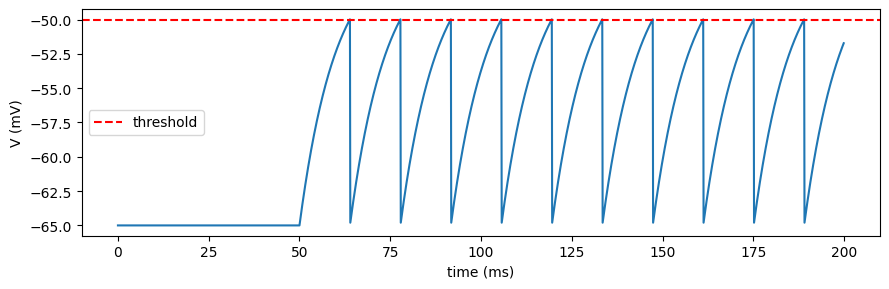

In [6]:
neuron = brainpy.state.LIF(
    1,
    V_rest=-65. * u.mV, V_th=-50. * u.mV, V_reset=-65. * u.mV,
    tau=10. * u.ms, spk_reset='hard',
)
brainstate.nn.init_all_states(neuron)

def step(t):
    with brainstate.environ.context(t=t):
        current = u.math.where(t > 50. * u.ms, 20. * u.mA, 0. * u.mA)
        neuron(jnp.ones(1) * current)
        return neuron.V.value

with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 200. * u.ms, brainstate.environ.get_dt())
    voltages = brainstate.transform.for_loop(step, times)

plt.figure(figsize=(9, 3))
plt.plot(times.to_decimal(u.ms), voltages.to_decimal(u.mV).squeeze())
plt.axhline(-50, color='r', ls='--', label='threshold')
plt.xlabel('time (ms)'); plt.ylabel('V (mV)'); plt.legend(); plt.tight_layout()
plt.show()

### `jit` for a single compiled call

When you call the same step repeatedly from your own outer logic, wrap it in
``jit`` so it compiles once and every subsequent call is fast:

In [7]:
@brainstate.transform.jit
def one_step(current):
    neuron(current)
    return neuron.get_spike()

brainstate.nn.init_all_states(neuron)
with brainstate.environ.context(dt=0.1 * u.ms, t=0. * u.ms):
    _ = one_step(jnp.ones(1) * 20. * u.mA)   # first call compiles
    _ = one_step(jnp.ones(1) * 20. * u.mA)   # subsequent calls are fast

## Recap

- A model is **state evolving in time**; ``brainstate.State`` makes that state
  explicit and visible to JAX's transformations.
- **``init_all_states``** allocates (and resets) dynamical variables, optionally
  batched.
- **``environ.context``** supplies ``dt`` and ``t``.
- **Drive models with ``transform``** (``jit`` / ``for_loop`` / ``scan`` /
  ``checkpointed_*``) — never a bare Python loop over time steps.

## See also

- {doc}`/concepts/physical-units` — the unit system every state carries.
- {doc}`/concepts/model-anatomy` — the ``Dynamics`` contract these states live in.
- {doc}`/concepts/alignpre-alignpost` — the keystone projection design.
- {doc}`/concepts/differentiability` — ``for_loop`` and ``checkpointed_*`` under
  ``grad`` for training.